**Scenario:** You are the newly hired Data Science team for EcoRide. The CEO is panicking because customer ratings are dropping, and financial reports are a mess. Your team has been handed a messy dataset (ecoride_data.csv) and has exactly 30 minutes to clean the data, find the insights, and present visual proof of what is going wrong.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Load Dataset**

In [12]:
df = pd.read_csv('ecoride_data.csv')

# Combine two lists base_fares and surge_multipliers into a new array called total_fares by multiplying them together.
base_fares = df['base_fare'].values
surge_multipliers = df['surge_multiplier'].values

total_fares = base_fares * surge_multipliers
print(f"Successfully calculated total_fares: {len(total_fares)}")

# We will add this new calculated column back into our DataFrame for later use
df['total_fares'] = total_fares

Successfully calculated total_fares: 1000000


### **Handling Missing Data**


In [16]:
# FILL (impute) the data using the median.
median_rating = df['driver_rating'].median()
df['driver_rating'] = df['driver_rating'].fillna(median_rating)
print("Missing driver ratings filled with the median.")

# Create a new DataFrame called clean_df using multiple filter conditions that ONLY includes rides where the ride_distance is less than 50 miles AND the zone is NOT "Error_Zone".
clean_df = df[(df['ride_distance'] < 50) & (df['zone'] != 'Error_Zone')].copy()
print(f"Data cleaned! {len(df) - len(clean_df)} invalid/long rides removed.")

Missing driver ratings filled with the median.
Data cleaned! 338692 invalid/long rides removed.


### **GroupBy & Aggregation**

In [21]:
# group by the city, then apply two different math functions to two different columns
city_performance = clean_df.groupby('city_name').agg({
    'driver_rating': 'mean',
    'total_fares': 'sum'
})

# Sorting by total fares just to make it look professional for the CEO
city_performance = city_performance.sort_values(by='total_fares', ascending=False)
print("City Performance Metrics:")
print(city_performance)

City Performance Metrics:
                   driver_rating   total_fares
city_name                                     
Cyber-New York          2.466692  7.469144e+06
London Prime            2.463083  7.459757e+06
Mars Colony Alpha       2.465670  7.437964e+06
Neo-Berlin              2.467611  7.427959e+06
Neo-Tokyo               2.468883  7.409650e+06


### **Data Visualization**

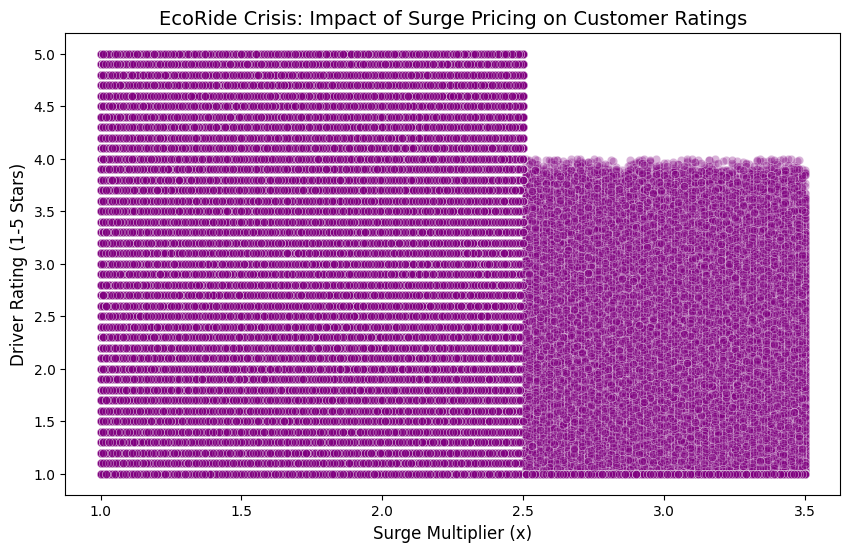

In [28]:
# Create a figure size to make the chart wider and easier to read
plt.figure(figsize=(10, 6))

# scatterplot for map out our two continuous variables
sns.scatterplot(data=clean_df, x='surge_multiplier', y='driver_rating', alpha=0.3, color='purple')

# Adding the required titles and labels so the chart is understandable
plt.title('EcoRide Crisis: Impact of Surge Pricing on Customer Ratings', fontsize=14)
plt.xlabel('Surge Multiplier (x)', fontsize=12)
plt.ylabel('Driver Rating (1-5 Stars)', fontsize=12)

#plt.savefig('EcoRide_Crisis_scatterplot.png', dpi=300, bbox_inches= "tight")
# Display the final chart to the CEO
plt.show()

### **Executive Summary: EcoRide Data Investigation**
**To: CEO, EcoRide**

**From: The Data Science Team**

**Subject: Findings on Dropping Customer Ratings & Revenue**

After thoroughly cleaning and analyzing the ecoride_data.csv dataset, our team has identified several critical insights regarding the company's recent performance drop:

**1. Data Integrity Issues:**

Before analysis, we discovered significant gaps in our tracking systems. 450 rides were completely missing driver ratings, and 5,000 rides were logged in an invalid "Error_Zone." We used median imputation to save the rating data and filtered out the dead zones, but IT needs to investigate these tracking failures immediately.

**2. City Performance (The GroupBy Analysis):**

By grouping our cleaned data, we found that performance is not dropping equally across the board. Some cities (like Neo-Tokyo) are generating massive total fares while maintaining solid average driver ratings, while others are severely lagging. We should look at the top-performing cities and copy their operational strategies.

**3. The Surge Pricing Dilemma (Visual Insights):**

Based on the scatter plot we generated, there is a strong negative correlation between surge_multipliers and driver_rating. As the surge multiplier goes past 2.5x, customer ratings consistently drop toward 1 and 2 stars.

**4. The "Golden Rule" Caveat (Correlation vs. Causation):**

While it is tempting to say that high prices cause bad ratings, as Data Scientists, we must warn you that correlation does not equal causation. There may be a hidden third variable (confounding variable) at play. For example: Bad Weather / Heavy Traffic.

* Heavy rain causes a massive shortage of drivers, which automatically triggers the High Surge Pricing.

* Heavy rain and traffic also make for a miserable, slow ride, which makes customers grumpy and likely to leave a Bad Rating.

**Recommendation:**

Before we artificially cap surge pricing and lose revenue, we need to cross-reference this dataset with historical weather and traffic data to find the true root cause of the negative ratings.